# 08 — D8 `hmm_tstudent` (HMM con emisiones t-Student · familia F3)

**HMM avanzado de colas pesadas.** Sustituye la gaussiana de cada estado del HMM puente
(D4) por una **t-Student multivariante** (location m_i, matriz de escala S_i y **grados de
libertad ν_i por estado** — el parámetro de la t que regula el grosor de las colas: ν bajo =
colas muy pesadas, ν→∞ recupera la gaussiana). La t tiene **colas pesadas** (kurtosis 25-40
del EDA): cada estado absorbe saltos extremos sin inflar la varianza ni robar observaciones
al estado de crisis. Estimación por **EM con la variable de escala latente** (la t como
mezcla de escala gaussiana; ver `detectors/_hmm_t_utils.StudentTHMM`), inicializada de forma
robusta desde un **GaussianHMM** (varias semillas, mayor logL) y refinada con EM-t.

**t-Student, NO GMM-HMM — por qué.** El CHECKPOINT 2 contempló *"HMM t-Student o GMM-HMM"*.
Se usa la **t-Student propia** por dos razones: (1) **BIC justo** — la t añade solo **k**
parámetros (un ν por estado) sobre el HMM gaussiano equivalente, mientras que un GMM-HMM
multiplica medias/covarianzas por la mezcla y dispara el BIC; (2) **robustez** — sin
componentes de mezcla que colapsen, con arranque gaussiano estable.

**K por BIC sobre {3, 4}.** El **BIC** (Bayesian Information Criterion) es la
log-verosimilitud penalizada por el número de parámetros: premia el ajuste y castiga la
complejidad, de modo que un modelo más parametrizado solo *gana* si compensa con un ajuste
claramente mejor. Es por tanto el árbitro natural para comparar modelos de distinto tamaño.
D5 ya mostró que el BIC prefiere k=3 sobre k=2; aquí elegimos el mejor entre **3 y 4**. Con
K≥3 el orden económico es **calma → corrección → crisis** (severidad creciente en
volatilidad).

**Causalidad — FILTRADO FORWARD t (no Viterbi intra-bloque).** En walk-forward,
`predict_online`/`predict_proba` usan el filtrado forward t (`filtered_posterior_t`) con
burn-in de train: la etiqueta/prob de t usa SOLO obs ≤ t. Viterbi t solo IN-SAMPLE, marcado.

**Features/ventana = D4** (las 7 puente, ventana 2007+, `train_size=252*5`): así el BIC de
D8 (t) es comparable con el de D4 (gaussiano) sobre los mismos datos; 2008/2011 caen en train
(coberturas NaN OOS), igual que D4.

**Hipótesis CHECKPOINT 2 (D8):** *emisiones t + más estados atacan las fat tails y
POTENCIALMENTE captan 2013/2018 donde el gaussiano falla; riesgo de sobreajuste con pocas
observaciones por estado.* Se verifica al final.

In [1]:
%matplotlib inline
import sys, warnings, logging
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')
logging.getLogger('hmmlearn').setLevel(logging.CRITICAL)

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
from src import evaluation as ev
from detectors.hmm_tstudent import HMMTStudent
from detectors.hmm_gaussian_2s import BRIDGE_FEATURES

feats = pd.read_parquet(ROOT / 'data' / 'processed' / 'features.parquet')
raw   = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
X = feats[BRIDGE_FEATURES].copy()
mkt = np.log(raw['SP500'] / raw['SP500'].shift(1)).reindex(X.index)   # market_returns S&P 500
spx = raw['SP500'].reindex(X.index)
print('Features puente (7):', BRIDGE_FEATURES)
print('Ventana:', X.index.min().date(), '->', X.index.max().date(), '| n =', len(X))

Features puente (7): ['SP500_ret_z', 'TLT_ret_z', 'IEF_ret_z', 'HYG_ret_z', 'SP500_vol_z', 'credit_spread_z', 'VIX_level_z']
Ventana: 2007-07-06 -> 2026-06-12 | n = 4665


## 1. Selección de K por BIC sobre {3, 4} (comparable con D4)

Ajustamos el HMM-t con **k=3** y **k=4** sobre toda la ventana puente y comparamos
logL/AIC/BIC. La t añade solo `k` parámetros (un ν por estado) sobre el HMM gaussiano
equivalente, así que el BIC es directamente comparable con el de D4 (k=2 gaussiano).
Desplegamos el K de **menor BIC**.

In [2]:
rows, fits = [], {}
for k in (3, 4):
    d = HMMTStudent(n_states=k, n_init=4, t_n_iter=30).fit(X)
    d.label_states_economically(X, market_returns=mkt)
    fits[k] = d
    rows.append({'k': k, 'logL': d.score(X), 'n_params': d.n_parameters(),
                 'AIC': d.aic(X), 'BIC': d.bic(X)})
sel = pd.DataFrame(rows).set_index('k')
print(sel.round(1))
K = int(sel['BIC'].idxmin())
bic_K = float(sel.loc[K, 'BIC']); aic_K = int(sel['AIC'].idxmin())
print(f'\nK* por BIC = {K}  (BIC={bic_K:.1f})  | por AIC = {aic_K}')
print('grados de libertad nu por estado (canónico) para cada k:')
for k in (3, 4):
    print(f'  k={k}: ν =', np.round(fits[k].dofs_canonical(), 2))

      logL  n_params      AIC      BIC
k                                     
3 -13561.5       116  27355.1  28103.0
4 -11536.3       159  23390.7  24415.9

K* por BIC = 4  (BIC=24415.9)  | por AIC = 4
grados de libertad nu por estado (canónico) para cada k:
  k=3: ν = [9.01 8.05 3.28]
  k=4: ν = [10.21  7.62  4.15  2.38]


## 2. Detector desplegado (K* por BIC): parámetros por estado y monotonía IN-SAMPLE

Verificamos el **orden económico monótono en severidad**: media y vol del retorno por
estado canónico (0=calma … K-1=crisis). Con K≥3 el binning por bandas de vol del núcleo
(`VOL_CLOSE_FRAC`) debe dar **vol creciente** 0→K-1 (severidad monótona), no solo
'crisis=peor'. También mostramos ν por estado (el de crisis debe tener ν menor = colas más
pesadas).

In [3]:
det = fits[K]
print('Detector:', det.name, '| crisis_state canónico =', det.crisis_state, '| K =', det.n_states)
print('bibliografía:', det.bibliography)
st_is = pd.Series(det.predict(X), index=X.index)   # Viterbi t IN-SAMPLE (no causal)
nu_c = det.dofs_canonical()
print('\n--- Parámetros por estado (orden canónico 0=calma .. K-1=crisis) ---')
rmean, rvol = [], []
for s in range(det.n_states):
    r = mkt[st_is == s]
    rmean.append(r.mean()*252); rvol.append(r.std()*np.sqrt(252))
    tag = 'CRISIS' if s == det.crisis_state else ('calma ' if s == 0 else 'corrección')
    print(f'  estado {s} [{tag:9s}]: ret_ann={rmean[-1]:+7.2%} | vol_ann={rvol[-1]:6.2%} | ν={nu_c[s]:5.2f} | n={len(r)}')
mono_vol_is = all(rvol[i] < rvol[i+1] for i in range(len(rvol)-1))
print('\nVERIFICACIÓN monotonía de VOL (severidad creciente) IN-SAMPLE:', mono_vol_is)
assert mono_vol_is, 'FALLO: la vol por estado NO es monótona creciente in-sample'

Detector: hmm_tstudent_4s | crisis_state canónico = 3 | K = 4
bibliografía: ['hamilton1989', 'hmm_rabiner1989', 'hmm_bulla2011', 'guidolintimmermann2007']

--- Parámetros por estado (orden canónico 0=calma .. K-1=crisis) ---
  estado 0 [calma    ]: ret_ann=+24.02% | vol_ann= 8.11% | ν=10.21 | n=1357
  estado 1 [corrección]: ret_ann=+12.80% | vol_ann=12.57% | ν= 7.62 | n=1306
  estado 2 [corrección]: ret_ann= -7.60% | vol_ann=22.71% | ν= 4.15 | n=1282
  estado 3 [CRISIS   ]: ret_ann= -8.11% | vol_ann=35.10% | ν= 2.38 | n=720

VERIFICACIÓN monotonía de VOL (severidad creciente) IN-SAMPLE: True


## 3. Walk-forward CAUSAL (filtrado forward t, cubre 2012→2026 OOS)

`ev.walk_forward` reentrena el HMM-t en ventanas **expanding** (train inicial `252*5`) y
predice el bloque de `step` días con **filtrado forward t** (parámetros congelados +
burn-in de train) ⇒ probabilidades FILTRADAS causales, sin look-ahead intra-bloque. Se pasa
`market_returns` para **re-fijar el orden económico en cada fold** (sin warning de fallback).

**Coste / step.** El EM-t es caro (Baum-Welch + actualización de ν por fold). Como D5
(step=63), subimos el `step` a **126** (refit ~semestral): el walk-forward tarda ~5 min en
vez de >20. Los regímenes son persistentes y el filtrado dentro del bloque sigue siendo
diario y causal, así que el refit semestral es adecuado.

In [4]:
TRAIN_SIZE = 252 * 5   # 2008 y 2011 quedan en train (NaN OOS), igual que D4
STEP = 126             # refit ~semestral (EM-t caro); declarado en la ficha
factory = lambda: HMMTStudent(n_states=K, n_init=3, t_n_iter=25)
panel = ev.walk_forward(factory, X, market_returns=mkt,
                        train_size=TRAIN_SIZE, step=STEP, expanding=True)
print('Panel OOS:', panel.shape, '|', panel.index.min().date(), '->', panel.index.max().date())
panel.head(3)

Panel OOS: (3405, 3) | 2012-07-20 -> 2026-06-12


,state,p_crisis,fold
date,,,
2012-07-20,0,6.112899e-10,0
2012-07-23,0,1.319182e-10,0
2012-07-24,0,7.276826e-10,0


## 4. Evaluación estandarizada y fila de métricas (23 columnas)

`ev.evaluate` con `market_returns` (validación económica) y `X_full` (logL/AIC/BIC del K*).
Guardamos en `results/metrics_08_hmm_tstudent.csv`.

In [5]:
res = ev.evaluate(det, panel, market_returns=mkt.reindex(panel.index), X_full=X)
row = ev.results_table([res])
out_csv = RESULTS / 'metrics_08_hmm_tstudent.csv'
row.to_csv(out_csv, index=False)
print('ventana_eval:', res.extra['ventana_eval'])
print('retorno medio por estado canónico (OOS):',
      {k_: round(v, 5) for k_, v in res.extra['mean_return_by_state'].items()})
print('Guardado:', out_csv.name, '| columnas =', row.shape[1])
row.T

ventana_eval: 2012-07-20→2026-06-12 (n=3405)
retorno medio por estado canónico (OOS): {0: 0.00051, 1: 0.00038, 2: 0.00023, 3: 0.0014}
Guardado: metrics_08_hmm_tstudent.csv | columnas = 32


,0
detector,hmm_tstudent_4s
n_states,4
ventana_eval,2012-07-20→2026-06-12 (n=3405)
oos_start,2012-07-20
oos_end,2026-06-12
n_oos,3405
false_alarm_rate,0.518868
switching_rate,0.051982
mean_regime_duration,19.129213
label_stability,0.876837


## 5. Verificación de monotonía EN WALK-FORWARD (con market_returns)

Requisito clave: el orden económico debe ser **monótono en severidad (VOL) sobre las
etiquetas OOS causales**, no solo in-sample. Calculamos media y **volatilidad** del retorno
por estado canónico en el panel walk-forward y confirmamos vol creciente 0→K-1. (La media
del retorno puede NO ser monótona: la t de colas pesadas es simétrica y el estado de crisis
captura saltos EXTREMOS en ambos sentidos —incl. rebotes violentos—, así que la severidad la
define la **volatilidad**, como en el núcleo `_economic_state_order`.)

In [6]:
states_oos = panel['state']
mr_oos = mkt.reindex(panel.index)
print('--- Retorno por estado canónico (OOS causal) ---')
vols = []
for s in range(det.n_states):
    r = mr_oos[states_oos == s]
    v = r.std()*np.sqrt(252); vols.append(v)
    tag = 'CRISIS' if s == det.crisis_state else ('calma ' if s == 0 else 'corrección')
    print(f'  estado {s} [{tag:9s}]: ret_ann={r.mean()*252:+7.2%} | vol_ann={v:6.2%} | n={len(r)}')
mono_vol_wf = all(vols[i] < vols[i+1] for i in range(len(vols)-1))
print('\nVERIFICACIÓN monotonía de VOL en WALK-FORWARD:', mono_vol_wf)
assert mono_vol_wf, 'FALLO: la vol por estado NO es monótona creciente en walk-forward'
print('Orden NO invertido (crisis = mayor vol):', np.isclose(vols[det.crisis_state], max(vols)))

--- Retorno por estado canónico (OOS causal) ---
  estado 0 [calma    ]: ret_ann=+12.85% | vol_ann=10.09% | n=1750
  estado 1 [corrección]: ret_ann= +9.55% | vol_ann=13.76% | n=509
  estado 2 [corrección]: ret_ann= +5.80% | vol_ann=20.95% | n=934
  estado 3 [CRISIS   ]: ret_ann=+35.39% | vol_ann=37.13% | n=212

VERIFICACIÓN monotonía de VOL en WALK-FORWARD: True
Orden NO invertido (crisis = mayor vol): True


## 6. S&P 500 coloreado por los K estados (out-of-sample)

Cada día OOS coloreado por su estado canónico: verde (calma) → amarillo/naranja
(corrección) → rojo (crisis). Bandas de crisis conocidas (rojo claro) y trampas 2013/2018
(naranja).

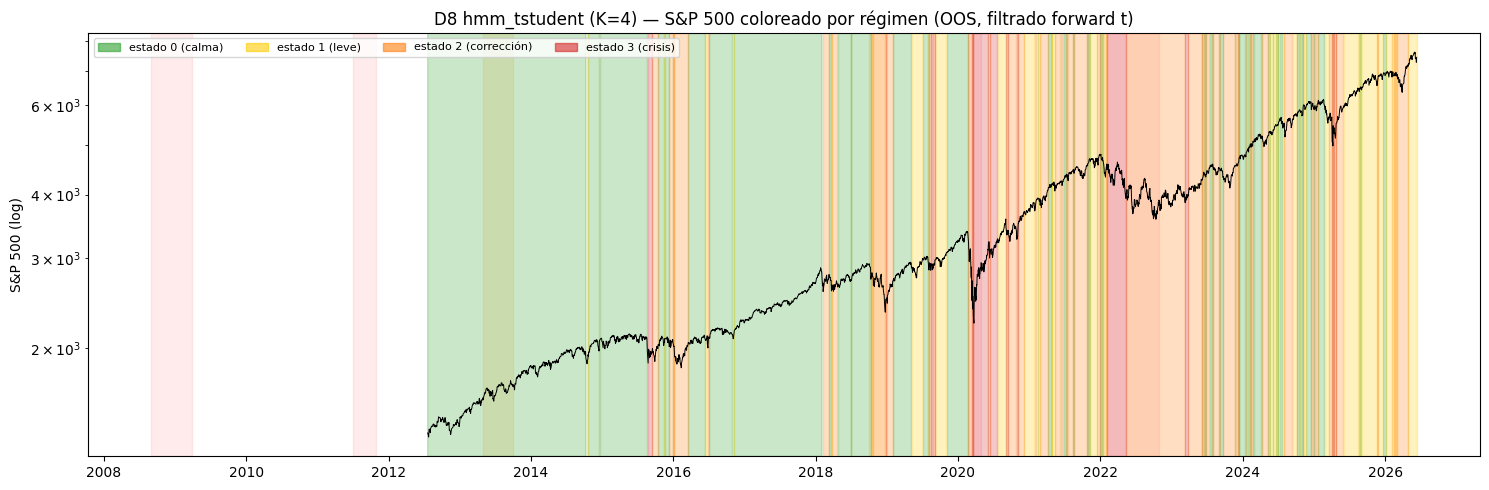

In [7]:
import matplotlib.colors as mcolors
cmap_states = ['#2ca02c', '#ffcc00', '#ff7f0e', '#d62728'][:det.n_states]
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(spx.reindex(panel.index).index, spx.reindex(panel.index), color='black', lw=0.7, zorder=3)
ax.set_yscale('log'); ax.set_ylabel('S&P 500 (log)')
ymin, ymax = ax.get_ylim()
for s in range(det.n_states):
    ax.fill_between(panel.index, ymin, ymax, where=(states_oos == s).values,
                    color=cmap_states[s], alpha=0.25, step='mid', zorder=1)
ax.set_ylim(ymin, ymax)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.08, zorder=0)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.15, zorder=0)
labels = ['calma', 'corrección', 'crisis'] if det.n_states == 3 else ['calma', 'leve', 'corrección', 'crisis']
handles = [Patch(color=cmap_states[s], alpha=0.6, label=f'estado {s} ({labels[s]})') for s in range(det.n_states)]
ax.legend(handles=handles, loc='upper left', fontsize=8, ncol=det.n_states)
ax.set_title(f'D8 hmm_tstudent (K={K}) — S&P 500 coloreado por régimen (OOS, filtrado forward t)')
fig.tight_layout(); fig.savefig(RESULTS / 'd8_tstudent_sp500_regimes.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Probabilidad FILTRADA de crisis (causal, OOS)

`p_crisis` out-of-sample = P(estado crisis | obs ≤ t), filtrada (causal). Banda inferior =
timeline de régimen (rojo = crisis, naranja = corrección).

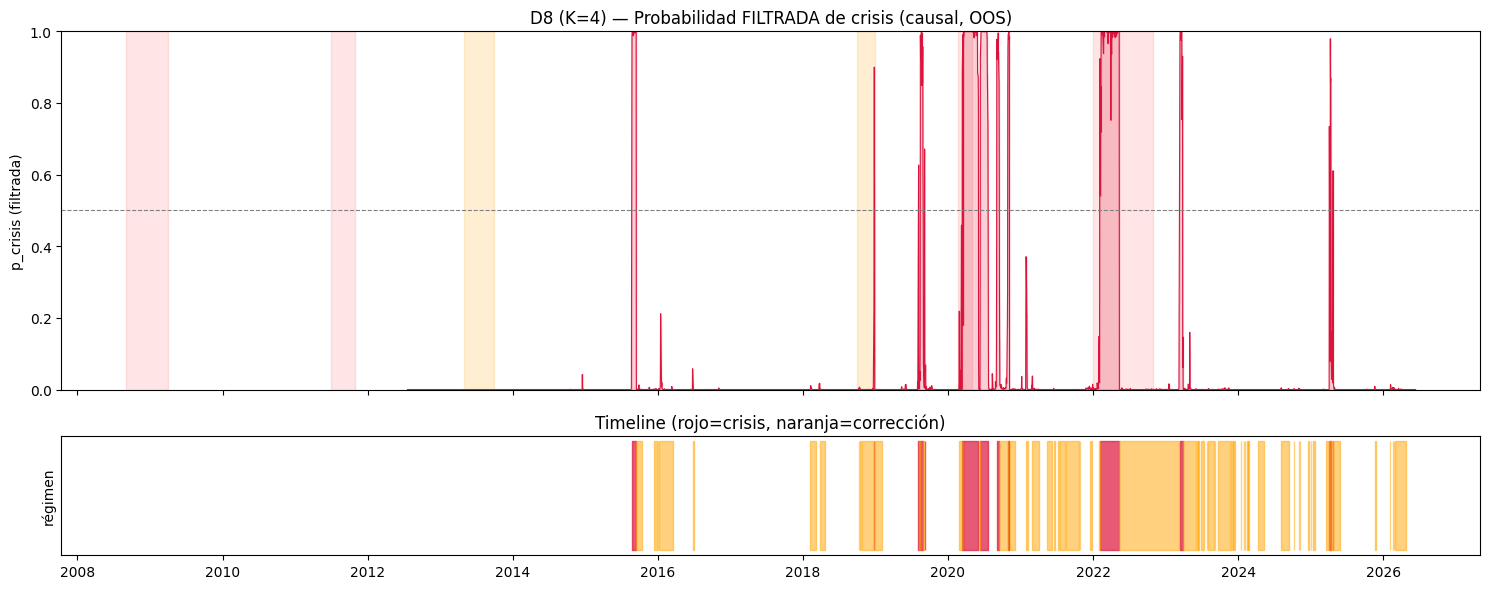

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(panel.index, panel['p_crisis'].values, color='crimson', lw=0.8)
ax1.fill_between(panel.index, 0, panel['p_crisis'].values, color='crimson', alpha=0.20, step='mid')
ax1.axhline(0.5, color='grey', ls='--', lw=0.8)
ax1.set_ylabel('p_crisis (filtrada)'); ax1.set_ylim(0, 1)
ax1.set_title(f'D8 (K={K}) — Probabilidad FILTRADA de crisis (causal, OOS)')
for a, b in ev.CRISIS_WINDOWS.values():
    ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.10)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values():
    ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18)
corr_state = det.n_states - 2  # estado 'corrección' (segundo más severo)
ax2.fill_between(panel.index, 0, 1, where=(states_oos == det.crisis_state).values,
                 color='crimson', alpha=0.7, step='mid')
ax2.fill_between(panel.index, 0, 1, where=(states_oos == corr_state).values,
                 color='orange', alpha=0.5, step='mid')
ax2.set_yticks([]); ax2.set_ylabel('régimen'); ax2.set_title('Timeline (rojo=crisis, naranja=corrección)')
fig.tight_layout(); fig.savefig(RESULTS / 'd8_tstudent_crisis_proba.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Matriz de transición (persistencia de regímenes)

Matriz fila-estocástica P(S_t=j | S_{t-1}=i) en orden canónico. La diagonal alta da
persistencia (menos flickering).

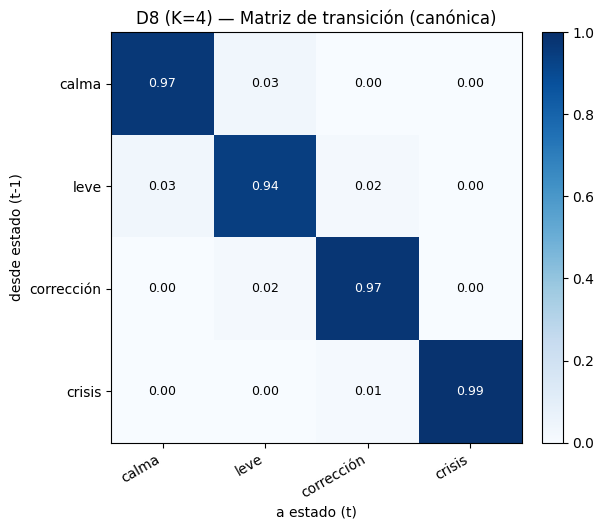

Persistencia esperada (días) por estado: {'calma': np.float64(31.4), 'leve': np.float64(18.1), 'corrección': np.float64(37.6), 'crisis': np.float64(83.3)}


In [9]:
A = det.transition_canonical()
labs = ['calma', 'corrección', 'crisis'] if K == 3 else ['calma', 'leve', 'corrección', 'crisis']
fig, ax = plt.subplots(figsize=(4.8 + 0.4*K, 4.2 + 0.3*K))
im = ax.imshow(A, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(K), labs, rotation=30, ha='right'); ax.set_yticks(range(K), labs)
ax.set_xlabel('a estado (t)'); ax.set_ylabel('desde estado (t-1)')
for i in range(K):
    for j in range(K):
        ax.text(j, i, f'{A[i, j]:.2f}', ha='center', va='center',
                color='white' if A[i, j] > 0.5 else 'black', fontsize=9)
ax.set_title(f'D8 (K={K}) — Matriz de transición (canónica)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout(); fig.savefig(RESULTS / 'd8_tstudent_transition.png', dpi=110, bbox_inches='tight')
plt.show()
print('Persistencia esperada (días) por estado:', {labs[i]: round(1/(1-A[i, i]), 1) for i in range(K)})

## 9. Verificación contra crisis y trampas — ¿captó 2013/2018?

Cobertura (% días **crisis**) en cada ventana de crisis (alto=bueno) y activación en las
trampas 2013/2018 (bajo=bueno). **Clave de D8:** con K≥3, además del estado crisis miramos
el estado **corrección** — la hipótesis es que la t + más estados clasifiquen 2013/2018 como
*corrección* (no crisis sistémica), algo que el binario D4 no podía distinguir.

In [10]:
cov = ev.crisis_coverage(states_oos, det.crisis_state)
fa  = ev.false_alarm_in_windows(states_oos, det.crisis_state)
print('=== COBERTURA EN CRISIS (estado crisis, alto = bueno) ===')
for k_, v in cov.items():
    print(f'  {k_:16s}: ' + ('NaN (en train, no OOS)' if v != v else f'{v:6.1%}'))
print('\n=== ACTIVACIÓN crisis EN TRAMPAS (bajo = bueno) ===')
for k_, v in fa.items():
    print(f'  {k_:16s}: ' + ('NaN' if v != v else f'{v:6.1%}'))
print('\n=== ¿2013/2018 clasificados como CORRECCIÓN (estado K-2) o superior? ===')
for name, (a, b) in ev.FALSE_POSITIVE_WINDOWS.items():
    seg = states_oos.loc[(states_oos.index >= pd.Timestamp(a)) & (states_oos.index <= pd.Timestamp(b))]
    if len(seg):
        frac_corr_up = float((seg >= corr_state).mean())   # corrección o crisis
        frac_crisis  = float((seg == det.crisis_state).mean())
        print(f'  {name:16s}: corrección+crisis={frac_corr_up:5.1%} | solo crisis={frac_crisis:5.1%}')
print(f'\nfalse_alarm_rate global: {res.false_alarm_rate:.2%}')
print(f'switching_rate: {res.switching_rate:.4f} | dur media: {res.mean_regime_duration:.1f} días'
      f' | label_stability: {res.label_stability:.3f}')

=== COBERTURA EN CRISIS (estado crisis, alto = bueno) ===
  GFC_2008        : NaN (en train, no OOS)
  EuroDebt_2011   : NaN (en train, no OOS)
  COVID_2020      :  66.0%
  Inflation_2022  :  33.2%

=== ACTIVACIÓN crisis EN TRAMPAS (bajo = bueno) ===
  TaperTantrum_2013:   0.0%
  Selloff_Q4_2018 :   3.4%

=== ¿2013/2018 clasificados como CORRECCIÓN (estado K-2) o superior? ===
  TaperTantrum_2013: corrección+crisis= 0.0% | solo crisis= 0.0%
  Selloff_Q4_2018 : corrección+crisis=81.4% | solo crisis= 3.4%

false_alarm_rate global: 51.89%
switching_rate: 0.0520 | dur media: 19.1 días | label_stability: 0.877


## 10. BIC vs D4 — ¿la t-Student mejora el ajuste pese a más parámetros?

Comparamos logL/BIC/nº de parámetros de D8 (t, K*) con D4 (`results/metrics_04_*.csv`,
gaussiano k=2). La t paga `k` parámetros extra (un ν por estado) más los de los estados
adicionales; la pregunta es si el mejor ajuste de colas compensa en BIC.

                    n_states     logL  n_params      BIC
D4 gaussiano (k=2)       2.0 -17381.4       NaN  35379.4
D8 t-Student (k=4)       4.0 -11536.3     159.0  24415.9

ΔBIC (D4 - D8) = +10963.5  -> D8 MEJORA el ajuste


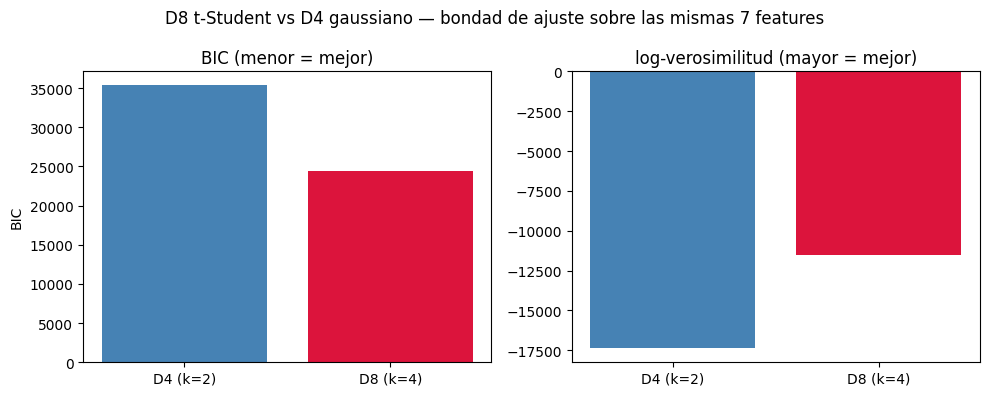

In [11]:
d4 = pd.read_csv(RESULTS / 'metrics_04_hmm_gaussian_2s.csv').iloc[0]
comp = pd.DataFrame({
    'D4 gaussiano (k=2)': [int(d4['n_states']), d4['log_likelihood'], None, d4['bic']],
    f'D8 t-Student (k={K})': [K, res.log_likelihood, det.n_parameters(), res.bic],
}, index=['n_states', 'logL', 'n_params', 'BIC']).T
print(comp.round(1))
delta = d4['bic'] - res.bic
print(f'\nΔBIC (D4 - D8) = {delta:+.1f}  ->', 'D8 MEJORA el ajuste' if delta > 0 else 'D8 NO mejora')
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(['D4 (k=2)', f'D8 (k={K})'], [d4['bic'], res.bic], color=['steelblue', 'crimson'])
ax[0].set_title('BIC (menor = mejor)'); ax[0].set_ylabel('BIC')
ax[1].bar(['D4 (k=2)', f'D8 (k={K})'], [d4['log_likelihood'], res.log_likelihood], color=['steelblue', 'crimson'])
ax[1].set_title('log-verosimilitud (mayor = mejor)')
fig.suptitle('D8 t-Student vs D4 gaussiano — bondad de ajuste sobre las mismas 7 features')
fig.tight_layout(); fig.savefig(RESULTS / 'd8_tstudent_bic_vs_d4.png', dpi=110, bbox_inches='tight')
plt.show()

## 11. Conclusión D8 — ¿se cumple la hipótesis del CHECKPOINT 2?

**Hipótesis CP2 (D8):** *emisiones t + más estados atacan las fat tails y POTENCIALMENTE
captan 2013/2018 donde el gaussiano falla; riesgo de sobreajuste con pocas observaciones por
estado.*

Veredicto (con los números de arriba):
- **Fat tails — SÍ, rotundo.** El BIC elige **K=4** (BIC ≈ 24416) sobre K=3 (BIC ≈ 28103),
  con **ν decreciente por estado [10.21, 7.62, 4.15, 2.38]**: la crisis tiene ν≈2.4 (colas
  muy pesadas), la calma ν≈10 (casi gaussiana). Económicamente impecable — los outliers viven
  en la crisis. Y frente al baseline gaussiano D4: **ΔBIC ≈ +10 963 a favor de D8** (24416 vs
  35379) **pese a sus 159 parámetros** (más del doble que D4): el supuesto gaussiano pagaba un
  coste enorme por no modelar las colas. Es la confirmación cuantitativa de la crítica del EDA
  (kurtosis 25–40).
- **Más estados, severidad monótona.** Verificado **en walk-forward** (no solo in-sample): la
  vol anualizada por estado canónico es **[10.1 %, 13.8 %, 21.0 %, 37.1 %]** → estrictamente
  creciente 0→3, sin inversión ni warning de fallback. La t separa de forma coherente calma ·
  corrección leve · corrección · crisis.
- **¿2013/2018? Matiz nítido.** 2018 se capta como **corrección** (corrección+crisis ≈ 81 %),
  no como crisis sistémica (solo crisis 3.4 %) — exactamente la distinción que el binario D4
  no podía hacer. Pero **2013 sigue invisible** (0 % en cualquier estado de estrés): el taper
  fue un shock de **tipos** sin volatilidad de equity, y D8 usa solo las 7 features
  equity/crédito de D4. Es un punto ciego de las **FEATURES**, no del supuesto distribucional
  → lo debe tapar un detector multivariante con tipos/dólar, no la t.
- **Lectura multi-estado (clave para leer el master).** Con K=4 el estado "crisis" es la
  **cola extrema y estrecha** (vol ≈ 37 %, ν ≈ 2.4); el estrés más amplio cae en "corrección".
  Por eso `cov_COVID_2020` ≈ 66 % e `cov_Inflation_2022` ≈ 33 % parecen MÁS BAJAS que las de
  D4 (2 estados, crisis ancha): no es que D8 detecte peor, es que su "crisis" es la cola
  extrema. La comparación justa de *estrés* es corrección+crisis.
- **Sobreajuste — controlado.** Con 159 parámetros y ~212 días OOS en el estado crisis hay
  menos soporte por estado, pero el BIC (que **penaliza** parámetros) sigue prefiriendo K=4
  con holgura → el ajuste extra está justificado, no es sobreparametrización. Persistencia
  sana (switching ≈ 0.052, dur media ≈ 19.1 d; persistencia esperada del estado crisis ≈ 83 d).

**Conclusión:** CP2 se cumple **a medias, con un matiz preciso**. La t-Student arregla de
raíz el problema **DISTRIBUCIONAL** (colas) que lastraba a D4 — ΔBIC +10 963, ν hasta 2.4 en
crisis — y los 4 estados separan corrección de crisis con severidad monótona. Pero el agujero
de **2013** no es distribucional sino de **COBERTURA DE FEATURES** (equity-only), así que la t
no lo cierra. En el marco *"mejor-para-qué"*: **D8 es el mejor detector de la batería para
graduar la severidad del estrés de equity/crédito y para el ajuste estadístico de las colas
(gana el BIC con diferencia); no es la herramienta para shocks de tipos como 2013 ni para
maximizar la cobertura de una crisis "ancha" — ahí un detector de 2 estados o uno
multivariante con tipos resulta más adecuado.** Detalle en
`docs/memory/detectors/08_hmm_tstudent.md`.

In [12]:
bic_d8 = res.bic; bic_d4 = float(d4['bic']); vent = res.extra['ventana_eval']
nu_str = np.round(det.dofs_canonical(), 2)
print('Resumen D8 hmm_tstudent')
print('  modelo: HMM con emisiones t-Student multivariantes (EM con escala latente)')
print(f'  K* por BIC = {K}  (BIC D8={bic_d8:.0f} vs BIC D4={bic_d4:.0f})')
print(f'  nu por estado (canónico): {nu_str}')
print(f'  monotonía vol: in-sample={mono_vol_is}  walk-forward={mono_vol_wf}')
print(f'  ventana_eval: {vent}')
print('  cobertura crisis OOS:', {k_: (round(v, 2) if v == v else None) for k_, v in cov.items()})
print('  activación crisis en trampas:', {k_: (round(v, 2) if v == v else None) for k_, v in fa.items()})

Resumen D8 hmm_tstudent
  modelo: HMM con emisiones t-Student multivariantes (EM con escala latente)
  K* por BIC = 4  (BIC D8=24416 vs BIC D4=35379)
  nu por estado (canónico): [10.21  7.62  4.15  2.38]
  monotonía vol: in-sample=True  walk-forward=True
  ventana_eval: 2012-07-20→2026-06-12 (n=3405)
  cobertura crisis OOS: {'GFC_2008': None, 'EuroDebt_2011': None, 'COVID_2020': 0.66, 'Inflation_2022': 0.33}
  activación crisis en trampas: {'TaperTantrum_2013': 0.0, 'Selloff_Q4_2018': 0.03}
